In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
pd.set_option('display.max_columns', None)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV, ParameterGrid


In [2]:
df_divar = pd.read_csv('Divar.csv')
df_city = pd.read_csv('iran_city_classification.csv')
df_divar = df_divar.merge(df_city ,  left_on='city_slug' , right_on='نام شهر' , how='left')
df_divar = df_divar.drop(columns='نام شهر')  

C:\Users\User\AppData\Local\Temp\ipykernel_4708\1474697002.py:1: DtypeWarning: Columns (11: rent_to_single, 27: floor, 29: total_floors_count, 53: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_divar = pd.read_csv('Divar.csv')


In [3]:
main_cats = ['residential-sell', 'residential-rent', 'commercial-sell', 'commercial-rent']

df_model = df_divar[df_divar["cat2_slug"].isin(main_cats)].copy()

In [4]:
text = (
    df_model["description"].fillna("") + " " +
    df_model["title"].fillna("")
)


villa_categories = [
    "villa",
    "house-villa-sell",
    "house-villa-rent"
]


villa_mask = df_model["cat3_slug"].isin(
    villa_categories
)


full_option_mask = text.str.contains(
    "فول امکانات|امکانات کامل|تمام امکانات",
    regex=True,
    na=False
)

df_model.loc[
    full_option_mask & ~villa_mask,
    [
        "has_elevator",
        "has_warehouse",
        "has_parking"
    ]
] = "true"

df_model.loc[
    full_option_mask & villa_mask,
    [
        "has_warehouse",
        "has_parking",
        "has_pool",
        "has_sauna",
        "has_jacuzzi",
        "has_barbecue"
    ]
] = "true"


for i, col in zip(["بالکن","آسانسور","نگهبان","باربیکیو","استخر","سونا","جکوزی","پارکینگ","انباری|انبار","سند تجاری"],
             ["has_balcony","has_elevator","has_security_guard","has_barbecue","has_pool"
              ,"has_sauna","has_jacuzzi","has_parking","has_warehouse","has_business_deed"]):

    mask = text.str.contains(
        i,
        regex=True,
        na=False
    )

    df_model.loc[mask,col] = "true"


In [5]:
binary_cols = [
    'has_business_deed',
    'has_balcony',
    'has_elevator',
    'has_warehouse',
    'has_parking',
    'is_rebuilt',
    'has_water',
    'has_electricity',
    'has_gas',
    'has_security_guard',
    'has_barbecue',
    'has_pool',
    'has_jacuzzi',
    'has_sauna'
]

for col in binary_cols:
    df_model[col] = df_model[col].replace({
            'true': True,
            'True': True,
            'false': False,
            'False': False,
            'unselect': np.nan
        })


for col in binary_cols:
    df_model[col] = df_model[col].fillna(False)

In [6]:
df_model['floor_material'] = df_model['floor_material'].replace('unselect' , np.nan)

In [7]:
weights = {
    'has_business_deed': 1,
    'has_balcony': 1,
    'has_elevator': 2,
    'has_warehouse': 2,
    'has_parking': 3,
    'is_rebuilt': 2,
    'has_water': 1,
    'has_electricity': 1,
    'has_gas': 1,
    'has_security_guard': 2,
    'has_barbecue': 1,
    'has_pool': 3,
    'has_jacuzzi': 3,
    'has_sauna': 3
}

df_model['amenity_score'] = sum(df_model[col] * weight for col , weight in weights.items())

df_model = df_model.drop(columns=binary_cols)

In [8]:
# cat3_slug
df_model = df_model.dropna(subset=["cat3_slug"])


# rooms_count
rooms_map = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5
}

df_model["rooms_count"] = df_model["rooms_count"].map(rooms_map)


# construction_year
df_model["is_before_1370"] = (df_model["construction_year"].astype("string").eq("قبل از ۱۳۷۰").fillna(False).astype(int))

persian_digits = str.maketrans(
    '۰۱۲۳۴۵۶۷۸۹',
    '0123456789'
)

df_model["construction_year"] = (df_model["construction_year"].astype("string").str.translate(persian_digits))
df_model.loc[df_model["construction_year"] == "قبل از 1370", "construction_year"] = np.nan
df_model["construction_year"] = pd.to_numeric(df_model["construction_year"], errors="coerce")


# building_size
df_model["building_size"] = pd.to_numeric(df_model["building_size"], errors="coerce")
df_model = df_model.dropna(subset=["building_size"])


# floor
df_model["floor"] = (df_model["floor"].replace("30+", "30"))
df_model["floor"] = pd.to_numeric(df_model["floor"], errors="coerce")


# total_floors_count
df_model["total_floors_count"] = (df_model["total_floors_count"].replace({"unselect": np.nan, "30+": "30"}))
df_model["total_floors_count"] = pd.to_numeric(df_model["total_floors_count"], errors="coerce")


#unit_per_floor
df_model["unit_per_floor_more_than_8"] = (df_model["unit_per_floor"].astype("string").eq("more_than_8").fillna(False).astype(int))
df_model["unit_per_floor"] = (df_model["unit_per_floor"].replace({"unselect": np.nan, "more_than_8": "9"}))
df_model["unit_per_floor"] = pd.to_numeric(df_model["unit_per_floor"], errors="coerce")

In [9]:
df_model["created_at_month"] = pd.to_datetime(df_model["created_at_month"], errors="coerce")
df_model["ad_year_jalali"] = np.where(df_model["created_at_month"].dt.month <= 3, df_model["created_at_month"].dt.year - 622,df_model["created_at_month"].dt.year - 621)

df_model["building_age"] = (df_model["ad_year_jalali"] - df_model["construction_year"])
df_model.loc[df_model["building_age"] < 0, "building_age"] = 0

In [10]:
price_cols = [
    "price_value",
    "credit_value",
    "rent_value",
    "transformable_rent",
    "transformable_credit"
]

for col in price_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")


sale_mask = df_model["cat2_slug"].isin(["residential-sell", "commercial-sell"])
rent_mask = df_model["cat2_slug"].isin(["residential-rent", "commercial-rent"])


df_model["target_price"] = np.nan

df_model.loc[sale_mask, "target_price"] = (df_model.loc[sale_mask, "price_value"])

final_rent = np.where(
    df_model["rent_value"].notna() &
    (df_model["rent_value"] != 0),
    df_model["rent_value"],
    df_model["transformable_rent"]
)


final_credit = np.where(
    df_model["credit_value"].notna() &
    (df_model["credit_value"] != 0),
    df_model["credit_value"],
    df_model["transformable_credit"]
)

rent_to_credit_factor = 1_000_000 / 30_000   

df_model.loc[rent_mask, "target_price"] = (final_credit[rent_mask] + 
                                           final_rent[rent_mask] * rent_to_credit_factor)


df_model = df_model[df_model["target_price"].notna() & (df_model["target_price"] > 0)].copy()
df_model["target_log10"] = np.log10(df_model["target_price"])

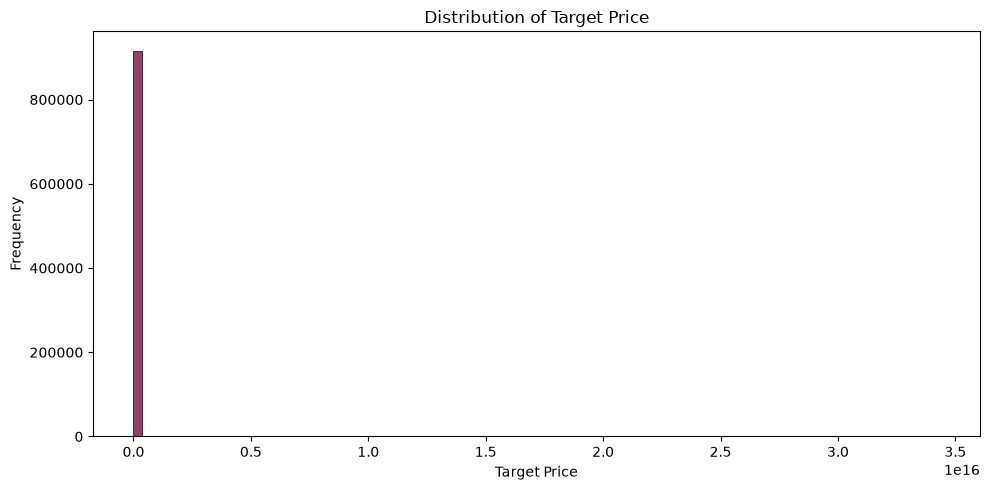

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(df_model["target_price"], bins=100, color="#730038")

plt.title("Distribution of Target Price")
plt.xlabel("Target Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

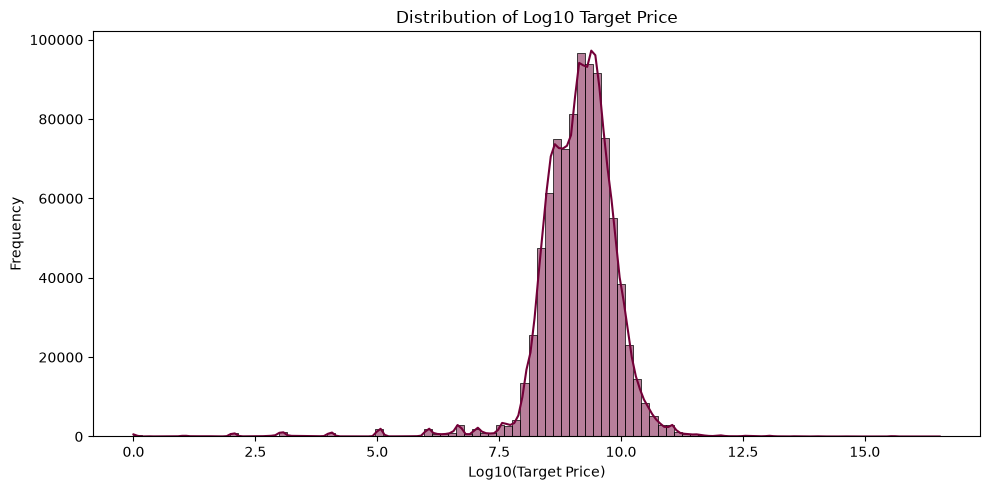

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(df_model["target_log10"], bins=100, kde=True, color="#730038")

plt.title("Distribution of Log10 Target Price")
plt.xlabel("Log10(Target Price)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [13]:
plot_mask = ((df_model["cat3_slug"] == "plot-old") & (df_model["rooms_count"].isna()))
df_model.loc[plot_mask, "rooms_count"] = 0

In [14]:
def fit_building_size_thresholds(data):
    stats = (data.groupby("cat3_slug")["building_size"].agg(q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75)))
    stats["iqr"] = stats["q3"] - stats["q1"]
    stats["upper_bound"] = (stats["q3"] + 3 * stats["iqr"])

    return stats["upper_bound"].to_dict()



def apply_building_size_cap(data, threshold_map):
    data = data.copy()
    upper = data["cat3_slug"].map(threshold_map)

    data["building_size_outlier"] = (data["building_size"] > upper).astype(int)
    mask = (data["building_size"].notna() & upper.notna() & (data["building_size"] > upper))
    data.loc[mask, "building_size"] = upper[mask]

    return data


def fit_target_iqr_bounds(data, target_col="target_log10", group_col="cat2_slug", iqr_factor=3):
    stats = (data.groupby(group_col)[target_col].agg(q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75)))
    stats["iqr"] = (stats["q3"] - stats["q1"])

    stats["lower_bound"] = (stats["q1"] - iqr_factor * stats["iqr"])
    stats["upper_bound"] = (stats["q3"] + iqr_factor * stats["iqr"])

    return stats

def remove_target_outliers(data, target_stats, target_col="target_log10", group_col="cat2_slug"):
    data = data.copy()

    lower_map = (target_stats["lower_bound"].to_dict())
    upper_map = (target_stats["upper_bound"].to_dict())

    lower_bound = (data[group_col].map(lower_map))
    upper_bound = (data[group_col].map(upper_map))

    outlier_mask = ((data[target_col] < lower_bound) | (data[target_col] > upper_bound))
    cleaned_data = (data.loc[~outlier_mask].copy())

    return cleaned_data, outlier_mask

In [15]:
print(df_model[["city_slug","neighborhood_slug","location_latitude", "location_longitude"]].isna().all(axis=1).sum())
df_model = df_model[~(df_model[["city_slug", "neighborhood_slug",
                    "location_latitude", "location_longitude"]].isna().all(axis=1))]

2


In [16]:
feature_cols = [
    "cat2_slug_freq", 
    "cat3_slug_freq",
    "city_slug_freq",
    "neighborhood_slug_freq",
    "floor_material_freq",
    "building_size",
    "rooms_count",
    "construction_year",
    "is_before_1370",
    "building_age",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "unit_per_floor_more_than_8",
    "amenity_score",
    "building_size_outlier",
    "location_latitude",
    "location_longitude",

]
categorical_cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
    "floor_material"
]

In [17]:

train_data, test_data = train_test_split(
    df_model,
    test_size=0.10,
    random_state=42,
    stratify=df_model["cat2_slug"]
)


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


median_cols = [
    "construction_year",
    "building_age",
    "rooms_count"
]

structural_cols = [
    "floor",
    "total_floors_count",
    "unit_per_floor"
]

r2_scores_dummy = []
mae_scores_dummy = []
mse_scores_dummy = []

r2_scores_linear = []
mae_scores_linear = []
mse_scores_linear = []

r2_scores_svr = []
mae_scores_svr = []
mse_scores_svr = []

r2_scores_tree = []
mae_scores_tree = []
mse_scores_tree = []

r2_scores_bagging = []
mae_scores_bagging = []
mse_scores_bagging = []

r2_log_scores_dummy = []
mae_log_scores_dummy = []

r2_log_scores_tree = []
mae_log_scores_tree = []

r2_log_scores_bagging = []
mae_log_scores_bagging = []

prepared_folds = []

for train_idx, val_idx in kf.split(train_data):

    fold_train = train_data.iloc[train_idx].copy()
    fold_val = train_data.iloc[val_idx].copy()

    target_stats = fit_target_iqr_bounds(fold_train, target_col="target_log10", group_col="cat2_slug", iqr_factor=3)
    fold_train, target_outlier_mask = (remove_target_outliers(fold_train, target_stats, target_col="target_log10", group_col="cat2_slug"))

    #==============================================================
    known_train = fold_train[
        fold_train['neighborhood_slug'].notna() &
        fold_train['location_latitude'].notna() &
        fold_train['location_longitude'].notna()
    ].copy()
    missing_train = fold_train[
        fold_train['neighborhood_slug'].isna() &
        fold_train['location_latitude'].notna() &
        fold_train['location_longitude'].notna()
    ].copy()
    
    cord_known_train = known_train[
        ['location_latitude', 'location_longitude']
    ]

    cord_missing_train = missing_train[
        ['location_latitude', 'location_longitude']
    ]

    near_neighbors = NearestNeighbors(n_neighbors=1)

    near_neighbors.fit(cord_known_train)

    distances, indices = near_neighbors.kneighbors(
        cord_missing_train
    )
    fold_train.loc[
        missing_train.index,
        'neighborhood_slug'
    ] = known_train.iloc[
        indices.flatten()
    ]['neighborhood_slug'].values
    
    
    
    missing_val = fold_val[
        fold_val['neighborhood_slug'].isna() &
        fold_val['location_latitude'].notna() &
        fold_val['location_longitude'].notna()
    ].copy()

    cord_missing_val = missing_val[
        ['location_latitude', 'location_longitude']
    ]

   
    distances_val, indices_val = near_neighbors.kneighbors(
        cord_missing_val
    )

    
    fold_val.loc[
        missing_val.index,
        'neighborhood_slug'
    ] = known_train.iloc[
        indices_val.flatten()
    ]['neighborhood_slug'].values
    
    fold_train['neighborhood_slug'] = (
        fold_train['neighborhood_slug'].fillna('unknown')
    )

    fold_val['neighborhood_slug'] = (
        fold_val['neighborhood_slug'].fillna('unknown')
    )
    #==============================================================
    lat_mean = fold_train.groupby('city_slug')['location_latitude'].mean()
    lon_mean = fold_train.groupby('city_slug')['location_longitude'].mean()
    city_floor_mode = fold_train.groupby('city_slug')['floor_material'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    global_floor_mode = fold_train['floor_material'].mode().iloc[0]
    
    fold_train['location_latitude'] = fold_train['location_latitude'].fillna(fold_train['city_slug'].map(lat_mean))
    fold_train['location_longitude'] = fold_train['location_longitude'].fillna(fold_train['city_slug'].map(lon_mean))
    fold_val['location_latitude'] = fold_val['location_latitude'].fillna(fold_val['city_slug'].map(lat_mean))
    fold_val['location_longitude'] = fold_val['location_longitude'].fillna(fold_val['city_slug'].map(lon_mean))

    fold_train['floor_material'] =fold_train['floor_material'].fillna(fold_train['city_slug'].map(city_floor_mode)).fillna(global_floor_mode)
    fold_val['floor_material'] =fold_val['floor_material'].fillna(fold_val['city_slug'].map(city_floor_mode)).fillna(global_floor_mode)

    building_thresholds = fit_building_size_thresholds(fold_train)
    fold_train = apply_building_size_cap(fold_train, building_thresholds)
    fold_val = apply_building_size_cap(fold_val, building_thresholds)

    median_imputer = SimpleImputer(strategy="median", add_indicator=True)
    train_median = median_imputer.fit_transform(fold_train[median_cols])
    val_median = median_imputer.transform(fold_val[median_cols])

    median_feature_names = (median_imputer.get_feature_names_out(median_cols))
    train_median = pd.DataFrame(train_median, columns=median_feature_names, index=fold_train.index)
    val_median = pd.DataFrame(val_median, columns=median_feature_names, index=fold_val.index)

    fold_train = fold_train.drop(columns=median_cols)
    fold_val = fold_val.drop(columns=median_cols)

    fold_train = pd.concat([fold_train, train_median], axis=1)
    fold_val = pd.concat([fold_val, val_median], axis=1)


    structural_imputer = SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)
    train_structural = structural_imputer.fit_transform(fold_train[structural_cols])
    val_structural = structural_imputer.transform(fold_val[structural_cols])

    structural_feature_names = (structural_imputer.get_feature_names_out(structural_cols))
    train_structural = pd.DataFrame(train_structural, columns=structural_feature_names, index=fold_train.index)
    val_structural = pd.DataFrame(val_structural, columns=structural_feature_names, index=fold_val.index)

    fold_train = fold_train.drop(columns=structural_cols)
    fold_val = fold_val.drop(columns=structural_cols)

    fold_train = pd.concat([fold_train, train_structural], axis=1)
    fold_val = pd.concat([fold_val, val_structural], axis=1)
    

    for col in categorical_cols:
        fold_train[col] = (fold_train[col].fillna("unknown"))
        fold_val[col] = (fold_val[col].fillna("unknown"))

        freq_map = (fold_train[col].value_counts(normalize=True))

        fold_train[col + "_freq"] = (fold_train[col].map(freq_map).fillna(0))
        fold_val[col + "_freq"] = (fold_val[col].map(freq_map).fillna(0))
        

    indicator_cols = [col for col in fold_train.columns if col.startswith("missingindicator_")]
    model_feature_cols = (feature_cols + indicator_cols)
    
    X_train = fold_train[model_feature_cols].copy()
    X_val = fold_val[model_feature_cols].copy()

    y_train = fold_train["target_log10"].copy()
    y_val = fold_val["target_log10"].copy()

    prepared_folds.append((X_train.astype("float32").to_numpy(), X_val.astype("float32").to_numpy(), y_train.to_numpy(), y_val.to_numpy()))


    # DummyReg
    model_dummy = DummyRegressor(strategy="median")
    model_dummy.fit(X_train, y_train)
    pred_log_dummy = model_dummy.predict(X_val)
    pred_dummy = 10 ** pred_log_dummy
    actual_dummy = 10 ** y_val
    

    r2_scores_dummy.append(r2_score(actual_dummy, pred_dummy))
    mae_scores_dummy.append(mean_absolute_error(actual_dummy, pred_dummy))
    mse_scores_dummy.append(mean_squared_error(actual_dummy, pred_dummy))
    r2_log_scores_dummy.append(r2_score(y_val, pred_log_dummy))
    mae_log_scores_dummy.append(mean_absolute_error(y_val, pred_log_dummy))

    # DecisionTreeRegressor
    model_tree = DecisionTreeRegressor(random_state=42)
    model_tree.fit(X_train, y_train)

    pred_log_tree = model_tree.predict(X_val)
    pred_tree = 10 ** pred_log_tree
    actual_tree = 10 ** y_val

    r2_scores_tree.append(r2_score(actual_tree, pred_tree))
    mae_scores_tree.append(mean_absolute_error(actual_tree, pred_tree))
    mse_scores_tree.append(mean_squared_error(actual_tree, pred_tree))
    r2_log_scores_tree.append(r2_score(y_val, pred_log_tree))
    mae_log_scores_tree.append(mean_absolute_error(y_val, pred_log_tree))


    # BaggingRegressor
    base_tree = DecisionTreeRegressor(random_state=42)
    model_bagging = BaggingRegressor(estimator=base_tree, n_estimators=10, random_state=42, n_jobs=-1)
    model_bagging.fit(X_train, y_train)

    pred_log_bagging = model_bagging.predict(X_val)
    pred_bagging = 10 ** pred_log_bagging
    actual_bagging = 10 ** y_val

    r2_scores_bagging.append(r2_score(actual_bagging, pred_bagging))
    mae_scores_bagging.append(mean_absolute_error(actual_bagging, pred_bagging))
    mse_scores_bagging.append(mean_squared_error(actual_bagging, pred_bagging))
    r2_log_scores_bagging.append(r2_score(y_val, pred_log_bagging))
    mae_log_scores_bagging.append(mean_absolute_error(y_val, pred_log_bagging))

In [18]:
results = pd.DataFrame({
    "Model": [
        "DummyRegressor",
        "DecisionTreeRegressor",
        "BaggingRegressor"
    ],

    # log-scale metrics
    "R2_log": [
        np.mean(r2_log_scores_dummy),
        np.mean(r2_log_scores_tree),
        np.mean(r2_log_scores_bagging)
    ],

    "MAE_log": [
        np.mean(mae_log_scores_dummy),
        np.mean(mae_log_scores_tree),
        np.mean(mae_log_scores_bagging)
    ],

    # original price-scale metrics
    "R2_real": [
        np.mean(r2_scores_dummy),
        np.mean(r2_scores_tree),
        np.mean(r2_scores_bagging)
    ],

    "MAE_real": [
        np.mean(mae_scores_dummy),
        np.mean(mae_scores_tree),
        np.mean(mae_scores_bagging)
    ],

    "MSE_real": [
        np.mean(mse_scores_dummy),
        np.mean(mse_scores_tree),
        np.mean(mse_scores_bagging)
    ],

    "R2_log_std": [
        np.std(r2_log_scores_dummy),
        np.std(r2_log_scores_tree),
        np.std(r2_log_scores_bagging)
    ]
})

results.sort_values("R2_log", ascending=False)

,Model,R2_log,MAE_log,R2_real,MAE_real,MSE_real,R2_log_std
2,BaggingRegressor,0.315445,0.265774,-0.00007,5.655775e+11,7.018354e+27,0.004821
1,DecisionTreeRegressor,0.207121,0.320004,-0.00007,5.663913e+11,7.018354e+27,0.005278
0,DummyRegressor,-0.006869,0.558039,-0.00007,5.673562e+11,7.018353e+27,0.000355


In [19]:
tree_param_grid = {
    "max_depth": [8, 12, 16, 20],
    "min_samples_split": [10, 30],
    "min_samples_leaf": [15, 20, 30],
}

tree_grid_results = []

for params in ParameterGrid(tree_param_grid):

    fold_r2 = []
    fold_mae = []
    fold_train_r2 = []

    for X_tr, X_v, y_tr, y_v in prepared_folds:

        model = DecisionTreeRegressor(random_state=42, **params)
        model.fit(X_tr, y_tr)

        pred_val = model.predict(X_v)
        pred_train = model.predict(X_tr)

        fold_r2.append(r2_score(y_v, pred_val))
        fold_mae.append(mean_absolute_error(y_v, pred_val))
        fold_train_r2.append(r2_score(y_tr, pred_train))

    tree_grid_results.append({
        **params,

        "mean_val_R2_log":
            np.mean(fold_r2),

        "std_val_R2_log":
            np.std(fold_r2),

        "mean_val_MAE_log":
            np.mean(fold_mae),

        "mean_train_R2_log":
            np.mean(fold_train_r2)
    })

tree_grid_df = pd.DataFrame(tree_grid_results)
tree_grid_df = tree_grid_df.sort_values("mean_val_R2_log", ascending=False)
tree_grid_df.head(10)

,max_depth,min_samples_leaf,min_samples_split,mean_val_R2_log,std_val_R2_log,mean_val_MAE_log,mean_train_R2_log
22,20,30,10,0.315625,0.005250,0.271794,0.751898
23,20,30,30,0.315625,0.005250,0.271794,0.751898
20,20,20,10,0.313988,0.004870,0.272862,0.763502
21,20,20,30,0.313988,0.004870,0.272862,0.763502
17,16,30,30,0.313953,0.005204,0.274480,0.737376
16,16,30,10,0.313953,0.005204,0.274480,0.737376
15,16,20,30,0.312989,0.004934,0.275028,0.743604
14,16,20,10,0.312989,0.004934,0.275028,0.743604
19,20,15,30,0.311970,0.005075,0.274148,0.772641
18,20,15,10,0.311970,0.005075,0.274148,0.772641


In [20]:
best_tree_row = tree_grid_df.iloc[0]

best_tree_params = {
    "max_depth":
        int(best_tree_row["max_depth"]),

    "min_samples_split":
        int(best_tree_row["min_samples_split"]),

    "min_samples_leaf":
        int(best_tree_row["min_samples_leaf"])
}

best_tree_params

{'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 30}

In [ ]:
best_base_tree = DecisionTreeRegressor(**best_tree_params, random_state=42)

bagging_param_grid = {
    "n_estimators": [10, 30],
    "max_samples": [0.7, 1.0],
}

bagging_grid_results = []

for params in ParameterGrid(bagging_param_grid):

    fold_r2 = []
    fold_mae = []
    fold_train_r2 = []

    for X_tr, X_v, y_tr, y_v in prepared_folds:

        model = BaggingRegressor(estimator=DecisionTreeRegressor(**best_tree_params,random_state=42), random_state=42, n_jobs=-1, **params)
        model.fit(X_tr,y_tr)

        pred_val = model.predict(X_v)
        pred_train = model.predict(X_tr)

        fold_r2.append(r2_score(y_v, pred_val))
        fold_mae.append(mean_absolute_error(y_v, pred_val))
        fold_train_r2.append(r2_score(y_tr, pred_train))

    bagging_grid_results.append({
        **params,

        "mean_val_R2_log":
            np.mean(fold_r2),

        "std_val_R2_log":
            np.std(fold_r2),

        "mean_val_MAE_log":
            np.mean(fold_mae),

        "mean_train_R2_log":
            np.mean(fold_train_r2)
    })

In [ ]:
bagging_grid_df = pd.DataFrame(bagging_grid_results)

bagging_grid_df = (bagging_grid_df.sort_values("mean_val_R2_log", ascending=False))
bagging_grid_df.head(10)

,max_samples,n_estimators,mean_val_R2_log,std_val_R2_log,mean_val_MAE_log,mean_train_R2_log
3,1.0,30,0.324739,0.005230,0.263501,0.753921
1,0.7,30,0.324426,0.005073,0.263757,0.749410
2,1.0,10,0.323379,0.005059,0.264831,0.751716
0,0.7,10,0.323122,0.005034,0.265160,0.746972


In [ ]:
best_bagging_row = (bagging_grid_df.iloc[0])
best_bagging_params = {
    "n_estimators":
        int(
            best_bagging_row[
                "n_estimators"
            ]
        ),

    "max_samples":
        float(
            best_bagging_row[
                "max_samples"
            ]
        )
}

best_bagging_params

{'n_estimators': 30, 'max_samples': 1.0}